## Proposed Dataset

This challenge uses the [Thalia dataset](https://arxiv.org/abs/2505.17782), a global multi-modal dataset for volcanic unrest monitoring. Thalia integrates InSAR, coherence, DEM, and atmospheric data across 38 spatiotemporal datacubes spanning 7 years of volcanic activity.

## Dependencies

In [ ]:
!pip install webdataset datasets huggingface_hub numpy matplotlib tqdm torch --quiet

In [ ]:
#Aggregate all imports
from huggingface_hub import login
from datasets import load_dataset
from huggingface_hub import list_repo_files
import matplotlib.pyplot as plt
import numpy as np
import pprint
import pandas as pd
from huggingface_hub import snapshot_download
import random
import webdataset
import json
import torch
import io

#TODO: upload the script somewhere for quick download.
import data_loading_utils as utils
import tqdm

In [ ]:
#Login via interactive mode. Requires a token from your hugging face account
login()

## Loading the Data

There are two options for accessing the dataset: streaming, where samples are downloaded on the fly, and a full local download. We use the latter for training, and the first for a quick inspection of the data

In [ ]:
#Stream data

DATASET_ID = "orion-ai-lab/Thalia"

ds_train      = load_dataset(DATASET_ID, split="train",      streaming=True)
ds_validation = load_dataset(DATASET_ID, split="validation", streaming=True)
ds_test       = load_dataset(DATASET_ID, split="test",       streaming=True)

print("Splits loaded in streaming mode.")
print("Train features:", ds_train.features)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/261 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/112 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/112 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/112 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/261 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/112 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/112 [00:00<?, ?it/s]

Splits loaded in streaming mode.
Train features: {'image.pth': List(List(List(Value('float32')))), 'labels.pth': List(List(List(Value('int64')))), 'sample.pth': {'annotation': List({'activity_type': List(Value('string')), 'atmospheric_fringes': Value('int64'), 'caption': Value('string'), 'confidence': Value('float64'), 'corrupted': Value('int64'), 'frameID': Value('string'), 'glacier_fringes': Value('int64'), 'image_artifacts': Value('int64'), 'intensity_level': List(Value('string')), 'is_crowd': Value('int64'), 'label': List(Value('string')), 'low_coherence': Value('int64'), 'no_info': Value('int64'), 'orbital_fringes': Value('int64'), 'phase': Value('string'), 'primary_date': Value('string'), 'processing_error': Value('int64'), 'secondary_date': Value('string'), 'segmentation_mask': List(List(Value('float64'))), 'uniqueID': Value('int64')}), 'annotation_path': List(Value('string')), 'frame_id': Value('string'), 'insar_path': List(Value('string')), 'label': List(Value('int64'))}, '__k

In [ ]:
# Let's see the file list
files = sorted(list_repo_files("orion-ai-lab/Thalia", repo_type="dataset"))
for f in files:
    print(f)

#Final structure:
#"webdatasets/{Chosen_Split}/{Temporality}/{Subset}/sample_shard_id.tar"

.gitattributes
README.md
webdatasets/spatiotemporal/1/test/sample-test-000000.tar
webdatasets/spatiotemporal/1/test/sample-test-000001.tar
webdatasets/spatiotemporal/1/test/sample-test-000002.tar
webdatasets/spatiotemporal/1/test/sample-test-000003.tar
webdatasets/spatiotemporal/1/test/sample-test-000004.tar
webdatasets/spatiotemporal/1/test/sample-test-000005.tar
webdatasets/spatiotemporal/1/test/sample-test-000006.tar
webdatasets/spatiotemporal/1/test/sample-test-000007.tar
webdatasets/spatiotemporal/1/test/sample-test-000008.tar
webdatasets/spatiotemporal/1/test/sample-test-000009.tar
webdatasets/spatiotemporal/1/test/sample-test-000010.tar
webdatasets/spatiotemporal/1/test/sample-test-000011.tar
webdatasets/spatiotemporal/1/test/sample-test-000012.tar
webdatasets/spatiotemporal/1/test/sample-test-000013.tar
webdatasets/spatiotemporal/1/test/sample-test-000014.tar
webdatasets/spatiotemporal/1/test/sample-test-000015.tar
webdatasets/spatiotemporal/1/test/sample-test-000016.tar
webdat

### Visualization of Thalia samples

Lets stream some data and visualize them

Caption for sample 1: Vertical stratification and turbulent mixing effects can be detected around the area. No deformation activity can be detected. 
Caption for sample 2: Vertical stratification effect of low intensity is detected in high altitude areas of the region. A sill-type deformation pattern of high intensity is detected at the bottom of the image. 
Caption for sample 3: Turbulent mixing effect is detected on the top and left side of the region. A sill-type deformation pattern of medium intensity is detected at the bottom of the image.
Caption for sample 4: Turbulent mixing effect can be detected on the left side of the region. A sill-type deformation pattern of high intensity can be detected on the central side.


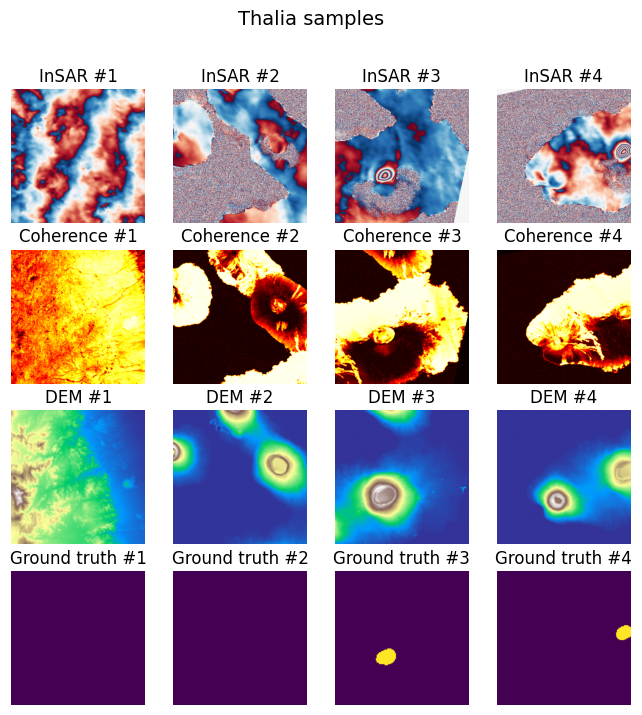

In [ ]:
samples = [s for _, s in zip(range(4), ds_test)]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("Thalia samples", fontsize=14)

for i, s in enumerate(samples):
    image = np.asarray(s["image.pth"])
    insar = image[0]
    coherence = image[1]
    dem = image[2]
    label = np.squeeze(np.asarray(s['labels.pth']))

    metadata = s['sample.pth']
    #Optional. Pretty print metadata to get an idea of provided info
    #pprint.pprint(metadata)
    # Print description of each sample
    caption = metadata['annotation'][0]['caption']
    print(f"Caption for sample {i+1}: {caption}")

    axes[0, i].imshow(insar, cmap="RdBu_r")
    axes[0, i].set_title(f"InSAR #{i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(coherence, cmap="hot")
    axes[1, i].set_title(f"Coherence #{i+1}")
    axes[1, i].axis("off")

    axes[2, i].imshow(dem, cmap="terrain")
    axes[2, i].set_title(f"DEM #{i+1}")
    axes[2, i].axis("off")

    axes[3, i].imshow(label)
    axes[3, i].set_title(f"Ground truth #{i+1}")
    axes[3, i].axis("off")

plt.show()

### Dataset split

Thalia offers two predefined data splits: a) temporal data split, and b) spatiotemporal data split.

**Temporal split**: All data with a primary SAR between January 1, 2014, and May 31, 2019 are assigned to the training set. Validation set covers the period from June 1, 2019, to December 31, 2019. Test set comprises samples collected between January 1, 2020, and December 31, 2021. This allows the model to learn the topography of each location and synthesize only on ground displacement and atmospheric contribution.

**Spatiotemporal split**: Three volcanic regions are reserved only for testing, i.e. the Galápagos Islands, the East African Rift System, and the South Aegean Volcanic Arc. The training set is defined as in the temporal split, while the validation set is extended till December 31, 2021. Utilizing this split is more challenging as models have no prior knowledge of the topography. A potential direction is to condition the generative model on the topography information.

In [ ]:
#Sample distribution per split

temporal = pd.DataFrame({
    ("",                  "Split"):     ["Training", "Validation", "Test", "Sum"],
    ("",                  "Dates"):     ["Jan 2014 – May 2019", "Jun 2019 – Dec 2019",
                                         "Jan 2020 – Dec 2021", "Jan 2014 – Dec 2021"],
    ("Single-Timestep",   "Positives"): [1143, 154,  509, 1806],
    ("Single-Timestep",   "Negatives"): [8697, 2416, 5992, 17105],
    ("Time-Series",       "Positives"): [701,  75,   225,  1001],
    ("Time-Series",       "Negatives"): [2626, 728,  1776, 5130],
})
temporal

Single-Timestep           Time-Series  \
        Split                Dates       Positives Negatives   Positives   
0    Training  Jan 2014 – May 2019            1143      8697         701   
1  Validation  Jun 2019 – Dec 2019             154      2416          75   
2        Test  Jan 2020 – Dec 2021             509      5992         225   
3         Sum  Jan 2014 – Dec 2021            1806     17105        1001   

             
  Negatives  
0      2626  
1       728  
2      1776  
3      5130

In [ ]:
spatiotemporal = pd.DataFrame({
    ("",                "Volcanic Region"): ["Galapagos", "East African Rift System",
                                             "South Aegean Volcanic Arc", "Sum"],
    ("Single-Timestep", "Positives"):       [866, 13, 0, 879],
    ("Single-Timestep", "Negatives"):       [318, 712, 351, 1381],
})
spatiotemporal

Single-Timestep          
             Volcanic Region       Positives Negatives
0                  Galapagos             866       318
1   East African Rift System              13       712
2  South Aegean Volcanic Arc               0       351
3                        Sum             879      1381

### Temporal Structure

Thalia provides time-series data by grouping InSAR pairs sharing the same primary SAR date and ordering them by secondary SAR date. Exploiting this temporal structure is a promising direction, though for simplicity this challenge focuses on single-timestep samples.

## Downloading the Dataset

We can either download the full dataset or work with a filtered subset — the latter being more practical under Colab's resource constraints. Both options are demonstrated below.

In [ ]:
#Download the full dataset. Adapt split (temporal/spatiotemporal) and temporality (1/3) accordingly.

local_path = snapshot_download(
    repo_id="orion-ai-lab/Thalia",
    repo_type="dataset",
    allow_patterns="webdatasets/temporal/1/**/*.tar",
    local_dir="./ThaliaDataset/",
)

Fetching 167 files:   0%|          | 0/167 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Downloading a fraction of the data

Given computational resource restrictions, we can download a portion of the dataset. We will keep the test and validation sets intact and subset the training set. We will keep all available positive instances (instances with volcanic unrest) for training and subset the negatives, which we have in abundance.

In [ ]:
local_path = snapshot_download(
    repo_id="orion-ai-lab/Thalia",
    repo_type="dataset",
    allow_patterns=[
        "webdatasets/temporal/1/test/*.tar",
        "webdatasets/temporal/1/val/*.tar",
        "webdatasets/temporal/1/train_neg/sample-train_neg-00000[0-1].tar",
        "webdatasets/temporal/1/train_pos/sample-train_pos-00000[0-1].tar",
    ],
    local_dir="./ThaliaFiltered",
)

Fetching 84 files:   0%|          | 0/84 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Lets download a toy version for demo convenience. We select the first two shards for each subset.
local_path = snapshot_download(
    repo_id="orion-ai-lab/Thalia",
    repo_type="dataset",
    allow_patterns=[
        "webdatasets/temporal/1/test/*00000[0-1].tar",
        "webdatasets/temporal/1/val/*00000[0-1].tar",
        "webdatasets/temporal/1/train_neg/sample-train_neg-00000[0-1].tar",
        "webdatasets/temporal/1/train_pos/sample-train_pos-00000[0-1].tar",
    ],
    local_dir="./ThaliaToy",
)

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

## Data loading

We now have our dataset. Let's try to iterate over it. As you may suspect, Thalia is stored in a webdataset format (See: https://github.com/webdataset/webdataset). This is done for efficiency as webdataset allows purely sequential I/O pipelines. Performing random access may result in major I/O bottleneck. Let's see how we can process such data.

In [ ]:
#Create some minimal configurations for the data loading. Flexible on the experiment design choices. (Also see here: https://github.com/Orion-AI-Lab/Thalia/blob/main/configs/configs.json)

configs = {
    #Random seed
    "seed": 333,

    #Input configs
    "geomorphology_channels": ["insar_difference", "insar_coherence", "dem"],
    "atmospheric_channels": ["total_column_water_vapour", "surface_pressure", "vertical_integral_of_temperature"],
    "timeseries_length":1,
    "mask_target": "union", # Each timestep has its individual ground truth mask. When using a timeseries, defining the sample-level mask may become ambiguous.
    "task": "segmentation", # We can also treat it as a classification task. This will return image-level
    "augment": False, # if Yes. Provide the list of augmentations as done in https://github.com/Orion-AI-Lab/Thalia/blob/main/configs/augmentations/augmentation.json
    "image_size": 512, # Resize input image to image_size x image_size

    #Webdataset configs
    "webdataset_root": "./ThaliaToy/webdatasets/temporal", # The root dir of the webdataset shards
    "webdataset_shuffle_size": 100, # Shuffle size for the webdataset
    "prefetch_factor": 2, # Prefetch factor for the dataloader
    "persistent_workers": False, # Persistent workers for the dataloader
    "webdataset_initial_buffer": 300, # Initial buffer size for the webdataset

    #Data loading configs
    "num_workers":2,
    "batch_size":12,
}

 Let's define the webdataset loaders

In [ ]:
train_loader, val_loader, test_loader = utils.create_webdataset_loaders(configs)

/usr/local/lib/python3.12/dist-packages/webdataset/compat.py:381: UserWarning: set WebDataset(shardshuffle=...) to a positive integer or 0 or False
  warnings.warn("set WebDataset(shardshuffle=...) to a positive integer or 0 or False")


### Iterating over our data

In [ ]:
for idx, batch in enumerate(tqdm.tqdm(train_loader)):
    image, label, metadata = batch
    # Lets check the shapes of our data. We have set time series length 1, image size 512x512, and 9 variables: InSAR, Coherence, DEM and 3 atmospheric variables for the Primary Date, +3 for the Secondary date.
    print("Image data shape: ",image.shape)
    print("Label shape: ",label.shape)
    print(metadata)
    break

0it [00:00, ?it/s]

Image data shape:  torch.Size([12, 9, 512, 512])
Label shape:  torch.Size([12, 512, 512])
[{'frame_id': '087D_07004_060904', 'insar_path': ['/mnt/nvme1/npapadopoulos/Hephaestus_Tiff/087D_07004_060904/interferograms/20180511_20180604/20180511_20180604.geo.diff_pha.tif'], 'annotation': [{'uniqueID': 6174, 'frameID': '087D_07004_060904', 'primary_date': '20180511', 'secondary_date': '20180604', 'corrupted': 0, 'processing_error': 0, 'glacier_fringes': 0, 'orbital_fringes': 0, 'atmospheric_fringes': 2, 'low_coherence': 0, 'no_info': 0, 'image_artifacts': 0, 'label': ['Deformation'], 'activity_type': ['Dyke', 'Sill', 'Dyke'], 'intensity_level': ['High', 'High', 'High'], 'phase': 'Unrest', 'confidence': 0.8, 'segmentation_mask': [[518.958984375, 527.5537109375, 509.2000000000007, 535.4000000000015, 505.3000000000011, 526.6000000000004, 507.5, 518.5, 505.28514902504867, 509.2407182603056, 512.3661062980391, 507.53152167717053, 520.1795763923728, 508.0198635580655, 524.5746533204365, 511.43825

0it [00:27, ?it/s]


# The floor is yours!